In [13]:
from neo4j import GraphDatabase
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

uri = "bolt://localhost:7687"
username = "neo4j"
password = "abcd90909090"

driver = GraphDatabase.driver(uri, auth=(username, password))

def run_query(query, parameters=None):
    with driver.session() as session:
        result = session.run(query, parameters)
        return [record.data() for record in result]


outgoing_rel = """
MATCH (n:UcoCVE)-[r]->(m)
RETURN labels(n), n.ucocveID, labels(m), type(r) AS Relationship
"""
params = {}

records = run_query(outgoing_rel, parameters=params)

df = pd.DataFrame(records)

df



,labels(n),n.ucocveID,labels(m),Relationship
0,"[Resource, UcoCVE]",None,"[Resource, UcoexCPE]",UCOEXHASCPE
1,"[Resource, UcoCVE]",None,"[Resource, UcoexCPE]",UCOEXHASCPE
2,"[Resource, UcoCVE]",None,"[Resource, UcoexCPE]",UCOEXHASCPE
3,"[Resource, UcoCVE]",None,"[Resource, UcoexCPE]",UCOEXHASCPE
4,"[Resource, UcoCVE]",None,"[Resource, UcoexCPE]",UCOEXHASCPE
...,...,...,...,...
602683,"[Resource, UcoCVE]",None,"[Resource, UcoexCPE]",UCOEXHASCPE
602684,"[Resource, UcoCVE]",None,"[Resource, UcoexCPE]",UCOEXHASCPE
602685,"[Resource, UcoCVE]",None,"[Resource, UcoexCPE]",UCOEXHASCPE
602686,"[Resource, UcoCVE]",None,"[Resource, UcoexCPE]",UCOEXHASCPE


In [73]:
incoming_rel = """
MATCH (n:UcoCVE)<-[r]-(m)
RETURN labels(n), n.ucocveID, labels(m), type(r) AS Relationship
"""
params = {}

records = run_query(incoming_rel, parameters=params)

df = pd.DataFrame(records)

df

,labels(n),n.ucocveID,labels(m),Relationship
0,"[Resource, UcoCVE]",None,"[Resource, UcoVulnerability]",UCOHASCVE_ID
1,"[Resource, UcoCVE]",None,"[Resource, UcoVulnerability]",UCOHASCVE_ID
2,"[Resource, UcoCVE]",None,"[Resource, UcoVulnerability]",UCOHASCVE_ID
3,"[Resource, UcoCVE]",None,"[Resource, UcoVulnerability]",UCOHASCVE_ID
4,"[Resource, UcoCVE]",None,"[Resource, UcoVulnerability]",UCOHASCVE_ID
...,...,...,...,...
281995,"[Resource, UcoCVE]",None,"[Resource, UcoVulnerability]",UCOHASCVE_ID
281996,"[Resource, UcoCVE]",None,"[Resource, UcoVulnerability]",UCOHASCVE_ID
281997,"[Resource, UcoCVE]",None,"[Resource, UcoVulnerability]",UCOHASCVE_ID
281998,"[Resource, UcoCVE]",None,"[Resource, UcoVulnerability]",UCOHASCVE_ID


In [15]:
undirected_rel = """
MATCH (n:UcoCVE)-[r]-(m)
RETURN labels(n), n.ucocveID, labels(m), type(r) AS Relationship
"""
params = {}

records = run_query(undirected_rel, parameters=params)

df = pd.DataFrame(records)

df

,labels(n),n.ucocveID,labels(m),Relationship
0,"[Resource, UcoCVE]",None,"[Resource, UcoVulnerability]",UCOHASCVE_ID
1,"[Resource, UcoCVE]",None,"[Resource, UcoexCPE]",UCOEXHASCPE
2,"[Resource, UcoCVE]",None,"[Resource, UcoVulnerability]",UCOHASCVE_ID
3,"[Resource, UcoCVE]",None,"[Resource, UcoVulnerability]",UCOHASCVE_ID
4,"[Resource, UcoCVE]",None,"[Resource, UcoexCPE]",UCOEXHASCPE
...,...,...,...,...
869449,"[Resource, UcoCVE]",None,"[Resource, UcoexCPE]",UCOEXHASCPE
869450,"[Resource, UcoCVE]",None,"[Resource, UcoVulnerability]",UCOHASCVE_ID
869451,"[Resource, UcoCVE]",None,"[Resource, UcoexCPE]",UCOEXHASCPE
869452,"[Resource, UcoCVE]",None,"[Resource, UcoVulnerability]",UCOHASCVE_ID


In [ ]:
def run_query(query, parameters=None):
    try:
        with driver.session() as session:
            result = session.run(query, parameters)
            return [record.data() for record in result]
    except Exception as e:
        print(f"Error running query: {e}")
        return []

def get_df(query, query_name):
    records = run_query(query)
    if records:
        df = pd.DataFrame(records)
        print(f"{query_name} query result:")
        print(df.head())
        print(f"Total {df.shape[0]} records loaded.\n")
        return df
    else:
        print(f"No results found for {query_name} query.")
        return pd.DataFrame()

outgoing_rel = """
MATCH (n:UcoCVE)-[r]->(m)
RETURN labels(n) AS NodeLabels, n.ucocveID AS UcoCVE_ID, labels(m) AS ConnectedNodeLabels, type(r) AS Relationship
"""

incoming_rel = """
MATCH (n:UcoCVE)<-[r]-(m)
RETURN labels(n) AS NodeLabels, n.ucocveID AS UcoCVE_ID, labels(m) AS ConnectedNodeLabels, type(r) AS Relationship
"""

undirected_rel = """
MATCH (n:UcoCVE)-[r]-(m)
RETURN labels(n) AS NodeLabels, n.ucocveID AS UcoCVE_ID, labels(m) AS ConnectedNodeLabels, type(r) AS Relationship
"""

df_outgoing = get_df(outgoing_rel, "Outgoing Relationships")
df_incoming = get_df(incoming_rel, "Incoming Relationships")
df_undirected = get_df(undirected_rel, "Undirected Relationships")


Outgoing Relationships query result:
           NodeLabels UcoCVE_ID   ConnectedNodeLabels Relationship
0  [Resource, UcoCVE]      None  [Resource, UcoexCPE]  UCOEXHASCPE
1  [Resource, UcoCVE]      None  [Resource, UcoexCPE]  UCOEXHASCPE
2  [Resource, UcoCVE]      None  [Resource, UcoexCPE]  UCOEXHASCPE
3  [Resource, UcoCVE]      None  [Resource, UcoexCPE]  UCOEXHASCPE
4  [Resource, UcoCVE]      None  [Resource, UcoexCPE]  UCOEXHASCPE
Total 626754 records loaded.

Incoming Relationships query result:
           NodeLabels UcoCVE_ID           ConnectedNodeLabels  Relationship
0  [Resource, UcoCVE]      None  [Resource, UcoVulnerability]  UCOHASCVE_ID
1  [Resource, UcoCVE]      None  [Resource, UcoVulnerability]  UCOHASCVE_ID
2  [Resource, UcoCVE]      None  [Resource, UcoVulnerability]  UCOHASCVE_ID
3  [Resource, UcoCVE]      None  [Resource, UcoVulnerability]  UCOHASCVE_ID
4  [Resource, UcoCVE]      None  [Resource, UcoVulnerability]  UCOHASCVE_ID
Total 282000 records loaded.

Undirect

              Outgoing  Incoming  Undirected
Relationship                                
UCOEXHASCPE     626754         0      626754
UCOHASCVE_ID         0    282000      282000


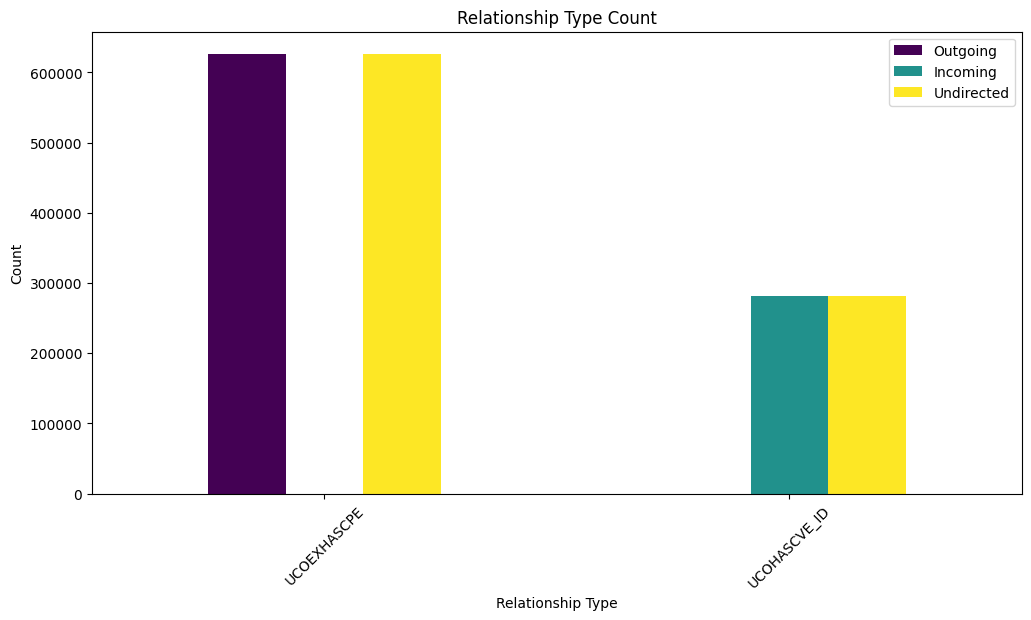

In [20]:
# Count the number of relationships for each type
outgoing_count = df_outgoing['Relationship'].value_counts()
incoming_count = df_incoming['Relationship'].value_counts()
undirected_count = df_undirected['Relationship'].value_counts()

# Create a summary DataFrame
summary_df = pd.DataFrame({
    'Outgoing': outgoing_count,
    'Incoming': incoming_count,
    'Undirected': undirected_count
}).fillna(0).astype(int)

# Display the summary
print(summary_df)

# Visualization
summary_df.plot(kind='bar', figsize=(12,6), colormap='viridis')
plt.title('Relationship Type Count')
plt.xlabel('Relationship Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


*Undirected* Connection Count per Node Type:
  ConnectedNodeType  ConnectionCount
0          Resource           908754
1          UcoexCPE           626754
2  UcoVulnerability           282000


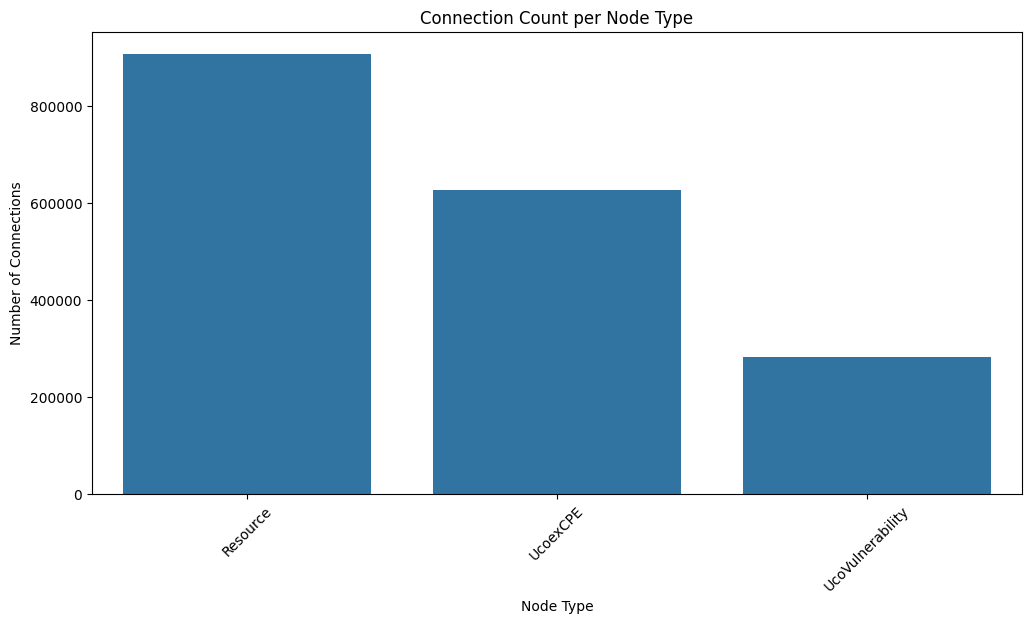

In [28]:
# Count connections per connected node type
node_type_count = df_undirected.explode('ConnectedNodeLabels')
node_type_summary = node_type_count['ConnectedNodeLabels'].value_counts().reset_index()
node_type_summary.columns = ['ConnectedNodeType', 'ConnectionCount']

# Display
print("*Undirected* Connection Count per Node Type:")
print(node_type_summary)

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=node_type_summary, x='ConnectedNodeType', y='ConnectionCount')
plt.title('Connection Count per Node Type')
plt.xlabel('Node Type')
plt.ylabel('Number of Connections')
plt.xticks(rotation=45)
plt.show()


*Incoming* Connection Count per Node Type:
  ConnectedNodeType  ConnectionCount
0          Resource           282000
1  UcoVulnerability           282000


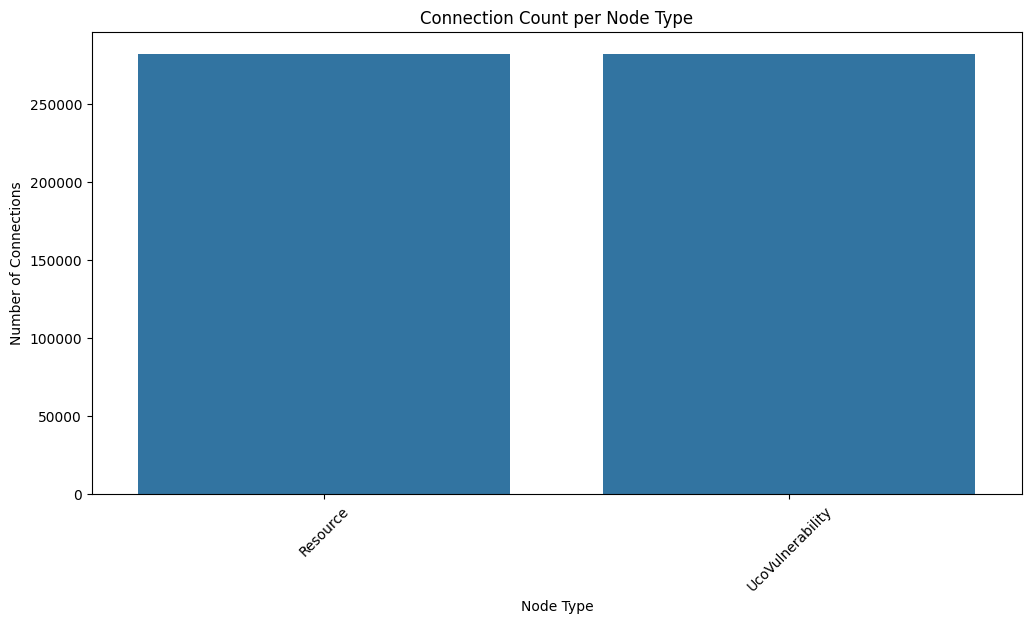

In [29]:
# Count connections per connected node type
node_type_count = df_incoming.explode('ConnectedNodeLabels')
node_type_summary = node_type_count['ConnectedNodeLabels'].value_counts().reset_index()
node_type_summary.columns = ['ConnectedNodeType', 'ConnectionCount']

# Display
print("*Incoming* Connection Count per Node Type:")
print(node_type_summary)

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=node_type_summary, x='ConnectedNodeType', y='ConnectionCount')
plt.title('Connection Count per Node Type')
plt.xlabel('Node Type')
plt.ylabel('Number of Connections')
plt.xticks(rotation=45)
plt.show()


*Outgoing* Connection Count per Node Type:
  ConnectedNodeType  ConnectionCount
0          Resource           626754
1          UcoexCPE           626754


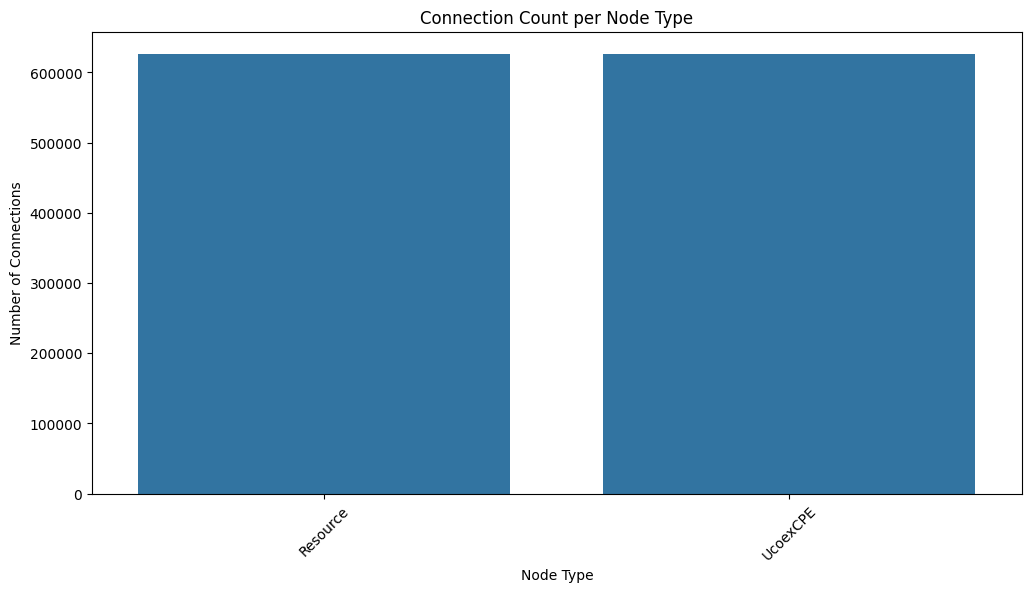

In [30]:
# Count connections per connected node type
node_type_count = df_outgoing.explode('ConnectedNodeLabels')
node_type_summary = node_type_count['ConnectedNodeLabels'].value_counts().reset_index()
node_type_summary.columns = ['ConnectedNodeType', 'ConnectionCount']

# Display
print("*Outgoing* Connection Count per Node Type:")
print(node_type_summary)

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=node_type_summary, x='ConnectedNodeType', y='ConnectionCount')
plt.title('Connection Count per Node Type')
plt.xlabel('Node Type')
plt.ylabel('Number of Connections')
plt.xticks(rotation=45)
plt.show()


In [34]:
query = """
MATCH (n:UcoCVE) RETURN count(n) AS UcoCVE
"""
params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

,UcoCVE
0,282000


In [74]:
query = """
MATCH (n:UcoexCPE) RETURN count(n) AS UcoexCPE
"""
params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

,UcoexCPE
0,133900


In [37]:
query = """
MATCH (n:UcoVulnerability) RETURN count(n) AS UcoVulnerability
"""
params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

,UcoVulnerability
0,282000


In [35]:
query = """
MATCH (n:UcoCVE)
UNWIND keys(n) AS key
RETURN DISTINCT key
"""
params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

,key
0,uri


In [51]:
query = """
MATCH (n:UcoCVE)<-[r]-(m:UcoVulnerability)
RETURN count(m) AS numOfUcoVulnerability, type(r) AS RelationshipType
"""
params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

,numOfUcoVulnerability,RelationshipType
0,282000,UCOHASCVE_ID


In [55]:
query = """
MATCH (n:UcoCVE)-[r]->(m:UcoexCPE)
RETURN count(m) AS numOfUcoexCPE, type(r) AS RelationshipType
"""
params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

,numOfUcoexCPE,RelationshipType
0,626754,UCOEXHASCPE


In [52]:
query = """
MATCH (n:UcoVulnerability)<-[r]-(m)
UNWIND labels(m) AS label
RETURN DISTINCT label AS targetNodeLabels
"""
params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

,targetNodeLabels
0,Resource
1,UcoExploitTarget


In [56]:
query = """
MATCH (n:UcoVulnerability)<-[r]-(m:UcoExploitTarget)
RETURN count(m) AS numOfUcoExploitTarget, type(r) AS RelationshipType
"""
params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

,numOfUcoExploitTarget,RelationshipType
0,213155,UCOHASVULNERABILITY


In [69]:
query = """
MATCH (n:UcoVulnerability)-[r]-()
RETURN DISTINCT type(r) AS relationshipType, count(r)
"""
params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

,relationshipType,count(r)
0,UCOHASCVE_ID,282000
1,UCOHASVULNERABILITY,213155


In [12]:
query = """
MATCH (n:UcoVulnerability)-[r]-(m)
UNWIND labels(m) AS label
RETURN DISTINCT label AS NodeType
"""
params = {}

records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df

,NodeType
0,Resource
1,UcoCVE
2,UcoExploitTarget


In [72]:
query = """
MATCH (n:UcoExploitTarget)-[r:UCOHASVULNERABILITY]->(m:UcoVulnerability)
RETURN 'UcoExploitTarget' AS SourceNode, 'UCOHASVULNERABILITY' AS Relationship,
        'UcoVulnerability' AS TargetNode, 
        COUNT(DISTINCT n) AS Source_Total, 
       COUNT(DISTINCT r) AS Relationship_Total, 
       COUNT(DISTINCT m) AS Target_Total
UNION
MATCH (n:UcoVulnerability)-[r:UCOHASCVE_ID]->(m:UcoCVE)
RETURN 'UcoVulnerability' AS SourceNode, 'UCOHASCVE_ID' AS Relationship,
        'UcoCVE' AS TargetNode, 
       COUNT(DISTINCT n) AS Source_Total, 
       COUNT(DISTINCT r) AS Relationship_Total, 
       COUNT(DISTINCT m) AS Target_Total
UNION
MATCH (n:UcoCVE)-[r:UCOEXHASCPE]->(m:UcoexCPE)
RETURN 'UcoCVE' AS SourceNode, 'UCOEXHASCPE' AS Relationship,
        'UcoexCPE' AS TargetNode, 
       COUNT(DISTINCT n) AS Source_Total, 
       COUNT(DISTINCT r) AS Relationship_Total, 
       COUNT(DISTINCT m) AS Target_Total
"""

params = {}
records = run_query(query, parameters=params)

df = pd.DataFrame(records)

df


,SourceNode,Relationship,TargetNode,Source_Total,Relationship_Total,Target_Total
0,UcoExploitTarget,UCOHASVULNERABILITY,UcoVulnerability,668,213155,197188
1,UcoVulnerability,UCOHASCVE_ID,UcoCVE,282000,282000,282000
2,UcoCVE,UCOEXHASCPE,UcoexCPE,242183,626754,133900
